# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

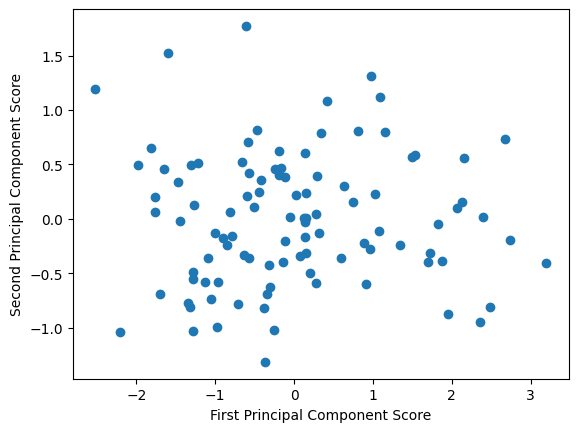

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

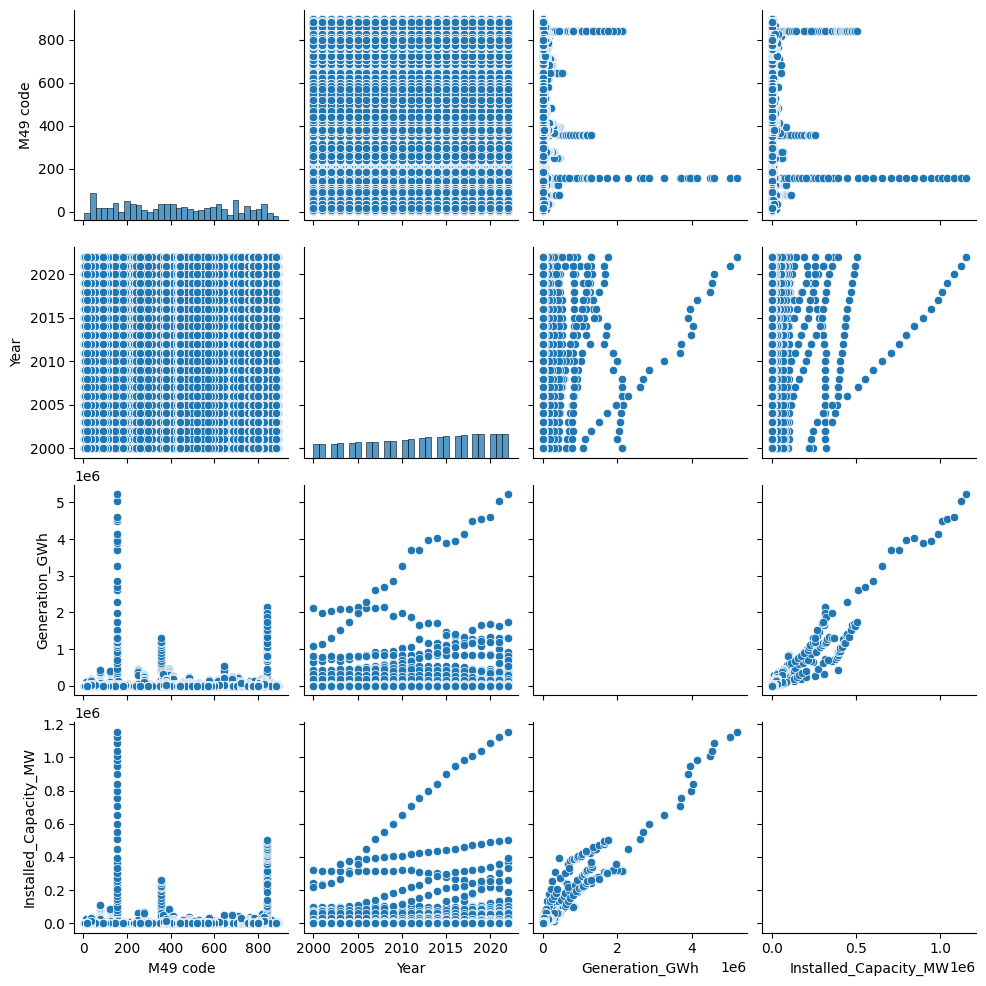

In [6]:
import seaborn as sns

# Draw pairplot of the 3 series
sns.pairplot(df)

### PCA Outlier Interpretation and Pairplot Discussion

#### PCA Scatter Plot:
The scatter plot shows data projected onto the first two principal components of `series_1`, `series_2`, and `series_3`. The outliers in the **upper left corner** of the PCA scatter have:

- **Very low values on the first principal component**, suggesting they strongly diverge from the dominant pattern in the data.
- **Moderately high values on the second principal component**, meaning they have unique variation not captured by PC1.

This suggests the outliers likely have:
- Much **lower values in `series_1` and `series_2`**
- And **higher values in `series_3`**, which contributes more to PC2 due to its higher variance.

#### Pairplot Interpretation:
From the pairplot:
- **`series_1` and `series_2`** show a **tight linear correlation** — expected, since `series_2` is a slight random variation on `series_1`.
- **`series_3`** is **more dispersed**, especially in its plots with `series_1` and `series_2`, due to its construction with more noise.

These visual patterns explain the PCA:
- PC1 reflects the shared trend in `series_1` and `series_2`.
- PC2 separates out the noisier behavior of `series_3`.

#### Advantages of PCA Plot:
- Reduces 3D data to 2D for easy visualization.
- Highlights structure, clusters, and outliers.

#### Disadvantages:
- The axes (principal components) are not intuitive — they are combinations of all variables.
- It's difficult to recover precise relationships between original variables (like `series_1` vs `series_2`) just from the PCA projection.

In [ ]:
# ===========================
# Super-Category Stacked Bar Chart (Inspired by p. 136)
# ===========================

# Use the cleaned dataset already loaded
df_irena = datasets["IRENA Renewable Energy"]

# Filter: only renewable energy, year 2020
df_filtered = df_irena[
    (df_irena["Year"] == 2020) &
    (df_irena["RE or Non-RE"] == "RE")
]

# Aggregate total generation by Region and Technology
df_grouped = df_filtered.groupby(["Region", "Technology"])["Generation_GWh"].sum().reset_index()

# Pivot for stacked bar chart format
df_pivot = df_grouped.pivot(index="Region", columns="Technology", values="Generation_GWh").fillna(0)

# Sort regions by total generation (optional, for clean visual)
df_pivot["Total"] = df_pivot.sum(axis=1)
df_pivot = df_pivot.sort_values("Total", ascending=False).drop(columns="Total")

# Plot
df_pivot.plot(kind="bar", stacked=True, figsize=(14, 6))
plt.title("2020 Renewable Electricity Generation by Region and Technology")
plt.xlabel("Region")
plt.ylabel("Generation (GWh)")
plt.xticks(rotation=45)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Loaded IRENA Renewable Energy: 35193 rows, 12 columns

Dataset: IRENA Renewable Energy
Total Rows: 35193, Total Columns: 12
Column Names: ['Region', 'Sub-region', 'Country', 'ISO3 code', 'M49 code', 'RE or Non-RE', 'Group Technology', 'Technology', 'Producer Type', 'Year', 'Electricity Generation (GWh)', 'Electricity Installed Capacity (MW)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35193 entries, 0 to 35192
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Region                               35193 non-null  object 
 1   Sub-region                           35193 non-null  object 
 2   Country                              35193 non-null  object 
 3   ISO3 code                            35193 non-null  object 
 4   M49 code                             35193 non-null  int64  
 5   RE or Non-RE                         35193 non-null  object 
 6   Group Technol

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

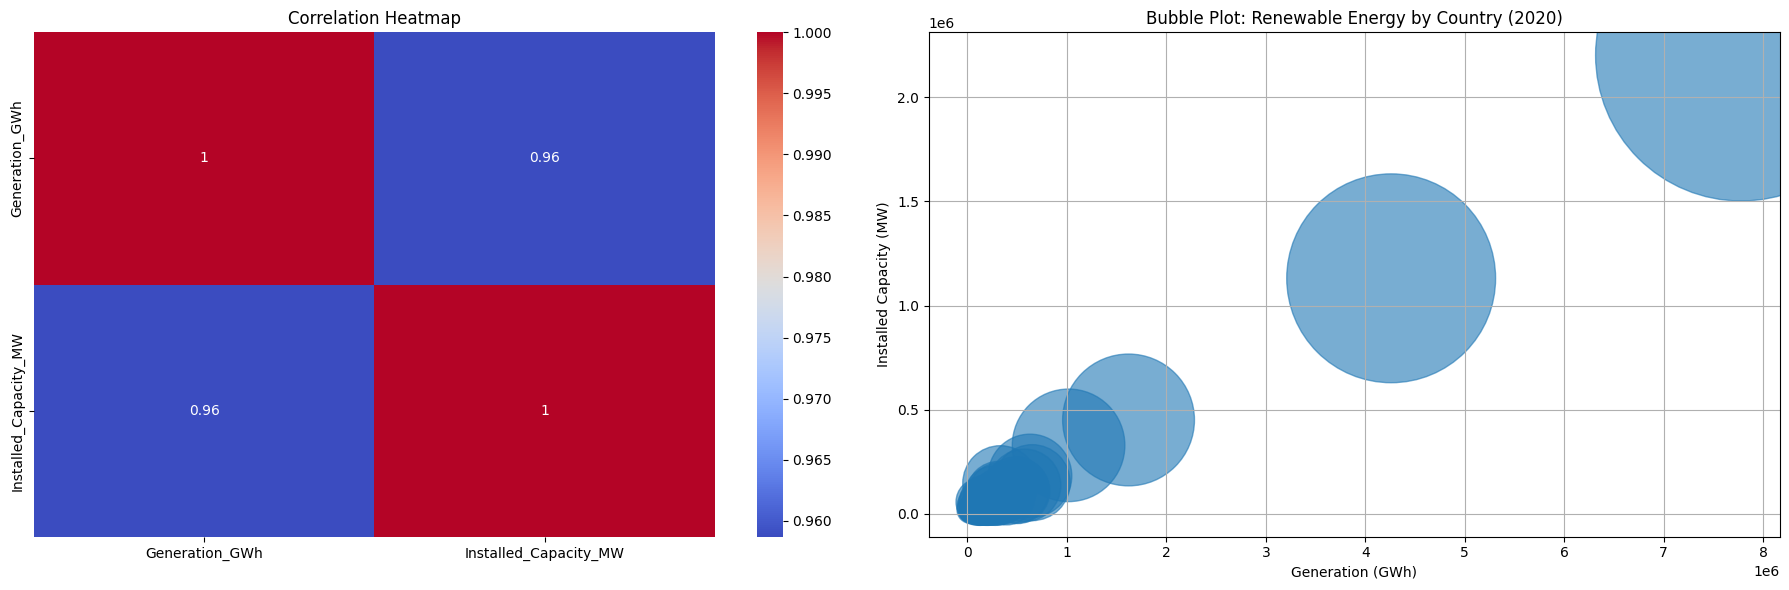

In [10]:
# ===========================
# Heatmap + Bubble Plot
# ===========================

import matplotlib.pyplot as plt
import seaborn as sns

# Data setup (reusing cleaned `df_irena`)
heatmap_data = df_irena[['Generation_GWh', 'Installed_Capacity_MW']].dropna()

year_filter = 2020
df_2020 = df_irena[df_irena['Year'] == year_filter].dropna(subset=['Generation_GWh', 'Installed_Capacity_MW'])

agg_2020 = df_2020.groupby('Country').agg({
    'Generation_GWh': 'sum',
    'Installed_Capacity_MW': 'sum'
}).reset_index()

# Create grid layout
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Correlation Heatmap")

# Bubble Plot
scatter = axes[1].scatter(
    agg_2020['Generation_GWh'],
    agg_2020['Installed_Capacity_MW'],
    s=agg_2020['Installed_Capacity_MW'] / 50,
    alpha=0.6
)
axes[1].set_xlabel("Generation (GWh)")
axes[1].set_ylabel("Installed Capacity (MW)")
axes[1].set_title(f"Bubble Plot: Renewable Energy by Country ({year_filter})")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Explained Variance Ratios: [0.97934466 0.02065534]


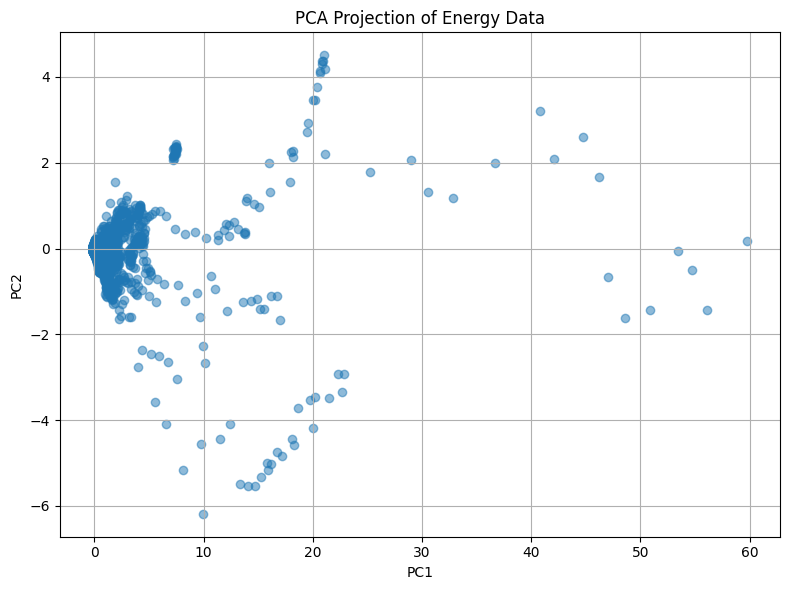

In [16]:
# ===========================
# Principal Component Analysis (PCA)
# ===========================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_data = df_irena[['Generation_GWh', 'Installed_Capacity_MW']].dropna()
scaled = StandardScaler().fit_transform(pca_data)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

print("Explained Variance Ratios:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.scatter(components[:, 0], components[:, 1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Energy Data")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# ===========================
# Linear Regression: Capacity -> Generation
# ===========================

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = pca_data[['Installed_Capacity_MW']]
y = pca_data['Generation_GWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, predictions):.4f}")

R² Score: 0.8734


In [13]:
# ===========================
# Outlier Detection (Z-score)
# ===========================

from scipy.stats import zscore

z_scores = np.abs(zscore(pca_data))
outliers = pca_data[(z_scores > 3).any(axis=1)]

print(f"Outliers Detected: {len(outliers)}")
display(outliers.head())

Outliers Detected: 211


,Generation_GWh,Installed_Capacity_MW
7716,374015.122,76869.0
7717,369556.400,77545.0
7718,390988.065,78610.0
7720,403289.813,80703.0
7722,428332.920,82457.0


## Section 3: Working on Your Datasets – Summary & Analysis

---

### Heatmap

The heatmap shows a **strong positive correlation (0.96)** between electricity generation and installed capacity. This makes sense — more capacity usually means more power produced. It also tells us that capacity is a solid predictor in regression and explains why PCA captures so much variance with just one component.

---

### Bubble Plot

The bubble plot compares countries based on their 2020 generation and capacity. Bigger bubbles mean more installed capacity. A few countries clearly stand out, while others show lower-than-expected generation, which could point to inefficiencies or different energy mixes.

---

### PCA (Principal Component Analysis)

PCA reduced the two features into principal components:

- PC1 explains ~98% of the variance
- PC2 explains ~2%

This means we could represent the data with just PC1 and still retain nearly all the information. The scatter plot from PCA also highlights some clustering and a few extreme outliers.

---

### Linear Regression

Using capacity to predict generation gave an **R² score of 0.87**, which is a strong result. This confirms what the correlation and PCA showed — installed capacity is a reliable predictor of how much electricity is generated.

---

### Outlier Detection

Using Z-scores, we flagged **211 outliers** — these are countries or years with really high or low values. Some are legit (like large producers), but others might be reporting issues or anomalies. Worth reviewing before using this data in sensitive models.

---

### Final Thoughts

The IRENA dataset is clean, easy to work with, and has strong patterns. It’s great for visualizations, PCA, and prediction. There’s clear structure, and while there are a few outliers, they’re manageable. Overall, it’s a solid dataset to explore renewable energy trends.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

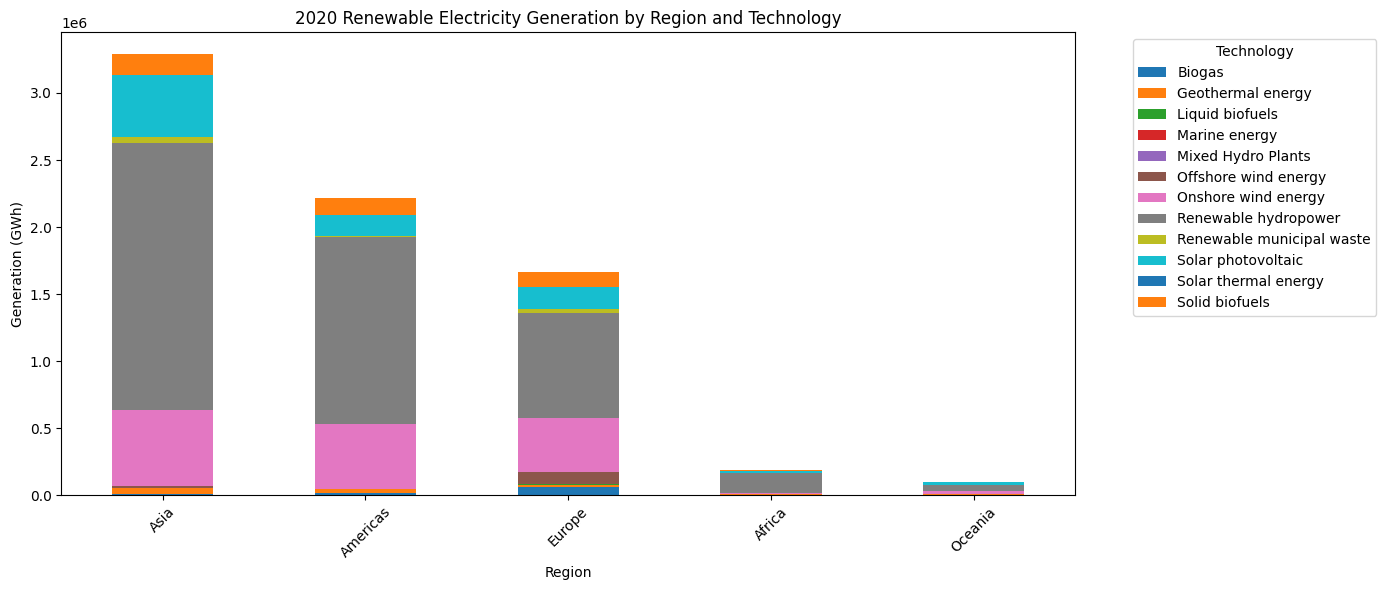

In [19]:
# ===========================
# Super-Category Stacked Bar Chart (Inspired by Storytelling with Data, p. 136)
# ===========================

import matplotlib.pyplot as plt

# Use pre-loaded and cleaned IRENA dataset
df_irena = datasets["IRENA Renewable Energy"]

# Filter for 2020, Total Renewable, and clean data
df_filtered = df_irena[
    (df_irena["Year"] == 2020) &
    (df_irena["RE or Non-RE"] == "Total Renewable") &
    (df_irena["Region"].notna()) &
    (df_irena["Technology"].notna()) &
    (df_irena["Generation_GWh"].notna())
]

# Aggregate total generation by Region and Technology
df_grouped = df_filtered.groupby(["Region", "Technology"])["Generation_GWh"].sum().reset_index()

# Pivot to create stacked bar structure
df_pivot = df_grouped.pivot(index="Region", columns="Technology", values="Generation_GWh").fillna(0)

# Sort by total generation for visual clarity
df_pivot["Total"] = df_pivot.sum(axis=1)
df_pivot = df_pivot.sort_values("Total", ascending=False).drop(columns="Total")

# Plot the chart
df_pivot.plot(kind="bar", stacked=True, figsize=(14, 6))
plt.title("2020 Renewable Electricity Generation by Region and Technology")
plt.xlabel("Region")
plt.ylabel("Generation (GWh)")
plt.xticks(rotation=45)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Question 4 – Storytelling With My Dataset

For this question, I recreated the stacked bar chart concept from *Storytelling with Data* by Cole Nussbaumer Knaflic, specifically from **page 136**, titled **“The Power of Super-Categories.”**

In my version, I used the IRENA dataset and focused on **2020 renewable electricity generation**, grouping countries by **Region** (the super-categories) and stacking by **Technology**. This approach mirrors the one shown in the book, where details are grouped to simplify comparisons and emphasize broader trends.

By using regions instead of individual countries, and stacking the generation types (like hydro, solar, wind, etc.), the chart is easier to interpret and tells a clearer story about which areas are leading in renewable adoption and how their energy mixes differ.

Following the book's guidance, I kept the design clean with minimal clutter, used color purposefully, and placed the legend outside the plot to improve readability. The end result is a more impactful and audience-friendly visualization that simplifies complexity without losing meaning.